In [1]:
import caustics
from caustics import Module, forward, Param
from torch.nn.functional import conv2d, avg_pool2d
import numpy as np
import torch
from torch import pi
import matplotlib.pyplot as plt

In [2]:
class Singlelens(Module):
    def __init__(
        self,
        lens,
        lens_light,
        source,
        pixelscale,
        pixels_x,
        upsample_factor,
        psf=None,
        name: str = "sim",
    ):
        super().__init__(name)

        self.lens = lens
        self.src = source
        self.lens_light = lens_light
        self.psf = Param("PSF", psf)
        self.upsample_factor = upsample_factor

        # Create the high-resolution grid
        thx, thy = caustics.utils.meshgrid(
            pixelscale / upsample_factor,
            upsample_factor * pixels_x,
            dtype=torch.float32,
        )

        self.thx = thx
        self.thy = thy

    @forward
    def run_simulator(self, psf):
        # Ray-trace to get the lensed positions
        bx, by = self.lens.raytrace(self.thx, self.thy)

        # Evaluate the lensed source brightness at high resolution
        image = self.src.brightness(bx, by)

        # Add the lens light
        image += self.lens_light.brightness(self.thx, self.thy)

        # Downsample to the desired resolution
        image_ds = avg_pool2d(image[None, None], self.upsample_factor)[0, 0]

        # Convolve with the PSF using conv2d
        psf_normalized = (psf.T / psf.sum())[None, None]
        image_ds = (
            conv2d(image_ds[None, None], psf_normalized, padding="same")
            .squeeze(0)
            .squeeze(0)
        )

        return image_ds

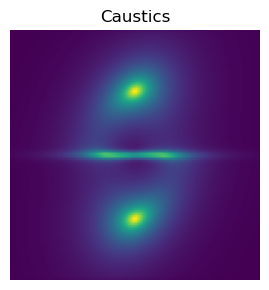

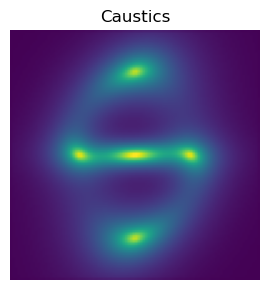

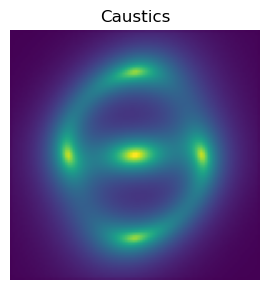

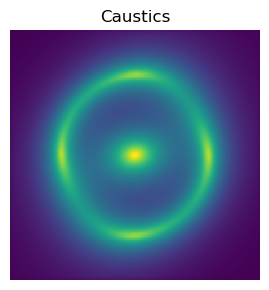

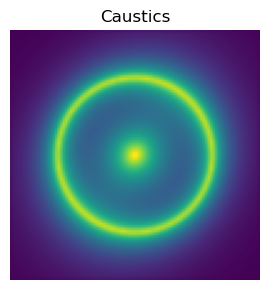

In [3]:
# Cosmology model
cosmology = caustics.FlatLambdaCDM(name="cosmo")

# PSF and image resolution
pixscale = 0.055  #0.11 / 2
fwhm = 0.1 # full width at half maximum of PSF
psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
n_psf = 11
psf_image = caustics.utils.gaussian(nx=n_psf, ny=n_psf, pixelscale=pixscale, sigma=psf_sigma, upsample=1,)


x = np.linspace(0.05, 1, 5, dtype=np.float32)
for i in range(len(x)):
    cx = x[i]
    
    # Mass model
    sie = caustics.SIE(cosmology=cosmology, name="lens", z_l=0.5, z_s=1.0, x0=0., y0=0.0, q=x[i], phi=0, Rein=1.7)
    # light source
    source_light = caustics.Sersic(name="source", x0=0, y0=0., q=0.7, phi=-0.985, n=1.3, Re=1.0, Ie=5) #5
    # light lens
    lens_light = caustics.Sersic(name="lenslight", x0=0., y0=0.0, q=x[i], phi=0.0, n=1, Re=1, Ie=10) #10
    
    # Instantiate simulator
    simulator = Singlelens(lens=sie, lens_light=lens_light, source=source_light, pixels_x=50 * 2, pixelscale=pixscale,
        upsample_factor=1, psf=psf_image, )

    # Set all parameters to be dynamic
    simulator.to_dynamic(children_only=False)
    cosmology.to_static()  # except cosmology parameters

    # Now create a flattened tensor
    params_for_simulator = simulator.get_values()
    lensed_image = simulator.run_simulator(params_for_simulator)

    plt.figure(figsize = (3,3))
    plt.title('Caustics', fontsize=12)
    plt.imshow(lensed_image)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('for_gif/caus_' + str(i) + '.png')
    plt.show()
    plt.close()

Params tensor shape:  torch.Size([143])
torch.Size([120, 120])


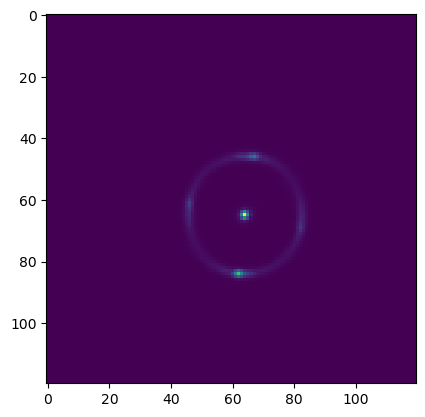

In [4]:
# Cosmology model
cosmology = caustics.FlatLambdaCDM(name="cosmo")

# System parameters for mass model and light profiles
epl = caustics.EPL(name="epl", cosmology=cosmology, z_s=3.5, z_l=1.5, x0=0.25, y0=0.3, q=1 / 1.14,
    phi=pi / 2 + 1.6755160819145565, Rein=1.036, t=1.04, )
source_light = caustics.Sersic(name="sourcelight", x0=0.25, y0=0.3, q=1 - 0.29, phi=-30 * pi / 180,
    n=4, Re=0.1, Ie=36, )
lens_light = caustics.Sersic(name="lenslight1", x0=0.25, y0=0.3, q=1 - 0.29, phi=-30 * pi / 180,
    n=4, Re=0.1, Ie=100, )

# PSF and image resolution
pixscale = 0.11 / 2
fwhm = 0.1  # full width at half maximum of PSF
psf_sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
n_psf = 11
psf_image = caustics.utils.gaussian(nx=n_psf, ny=n_psf, pixelscale=pixscale, sigma=psf_sigma, upsample=1,)

# Instantiate simulator
simulator = Singlelens(lens=epl, lens_light=lens_light, source=source_light, pixels_x=60 * 2, pixelscale=pixscale,
    upsample_factor=1, psf=psf_image, )

# Set all parameters to be dynamic
simulator.to_dynamic(children_only=False)
cosmology.to_static()  # except cosmology parameters

# Now create a flattened tensor
params_for_simulator = simulator.get_values()
print("Params tensor shape: ", params_for_simulator.shape)

lensed_image = simulator.run_simulator(params_for_simulator)
print(lensed_image.shape)

plt.imshow(lensed_image)
plt.show()